## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/nga_micron")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (5061, 10)
bivariate_df: (15183, 14)
joint_df: (723, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Abia,va_ai,27.378043,8.448417,194.951770,186.503353,0.101498,0.101498
1,cNF,1,Abia,fol_ai,16.206287,5.200761,104.187825,98.987064,0.111181,0.111181
2,cNF,1,Abia,vb12_ai,0.735096,0.125651,1.791460,1.665809,0.365855,0.365855
3,cNF,1,Abia,fe_ai,0.750524,0.385189,6.899481,6.514291,0.056082,0.056082
4,cNF,1,Abia,zn_ai,1.269604,0.446266,6.329845,5.883579,0.139938,0.139938


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Abia,va_ai,fol_ai,va_ai__fol_ai,0.816612,0.759322,0.057290,0.022264,0.827991,0.805727,0.043470,0.043470
1,cNF,1,Abia,va_ai,vb12_ai,va_ai__vb12_ai,0.494220,0.521930,0.027710,0.023942,0.539438,0.515496,0.007310,0.007310
2,cNF,1,Abia,va_ai,fe_ai,va_ai__fe_ai,0.738227,0.636275,0.101951,0.028448,0.819275,0.790826,0.092945,0.092945
3,cNF,1,Abia,va_ai,zn_ai,va_ai__zn_ai,0.569072,0.416849,0.152223,0.040818,0.527504,0.486687,0.228906,0.228906
4,cNF,1,Abia,va_ai,avg_adult_education,va_ai__avg_adult_education,-0.280245,-0.098473,0.181772,0.072303,0.290361,0.218059,0.502018,0.502018


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Abia,1.111239,600,600,0.420156,1.894762,1.474606,0.468656,0.468656
1,cNF,1,Abuja,1.196809,599,599,0.471811,2.161951,1.690140,0.428957,0.428957
2,cNF,1,Adamawa,1.125672,600,600,0.487123,2.323548,1.836425,0.347713,0.347713
3,cNF,1,Akwa Ibom,1.102672,600,600,0.477380,1.994632,1.517252,0.412121,0.412121
4,cNF,1,Anambra,1.063540,600,600,0.440729,1.904955,1.464226,0.425352,0.425352


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Abia,0.277454
1,CTGAN,1,Abuja,0.308493
2,CTGAN,1,Adamawa,0.199049
3,CTGAN,1,Akwa Ibom,0.325883
4,CTGAN,1,Anambra,0.158109


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Abia,0.470022
1,CTGAN,1,Abuja,0.369051
2,CTGAN,1,Adamawa,0.401401
3,CTGAN,1,Akwa Ibom,0.500939
4,CTGAN,1,Anambra,0.422320


,model,seed,adm1,joint_norm
0,cNF,1,Abia,0.468656
1,cNF,1,Abuja,0.428957
2,cNF,1,Adamawa,0.347713
3,cNF,1,Akwa Ibom,0.412121
4,cNF,1,Anambra,0.425352


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (723, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Abia,0.277454,0.470022,0.691598
1,CTGAN,1,Abuja,0.308493,0.369051,0.685070
2,CTGAN,1,Adamawa,0.199049,0.401401,0.465040
3,CTGAN,1,Akwa Ibom,0.325883,0.500939,0.624292
4,CTGAN,1,Anambra,0.158109,0.422320,0.612965


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/nga_micron/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.270866,0.428887,0.591591
1,CTGAN,2,0.274463,0.466952,0.578710
2,CTGAN,3,0.323079,0.404566,0.668377
3,CTGAN,4,0.248602,0.458357,0.546346
4,CTGAN,5,0.255137,0.396967,0.560215


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.274429,0.029235,0.431146,0.031234,0.589048,0.047595
1,NF,0.042600,0.004414,0.195845,0.001369,0.292566,0.004683
2,TVAE,0.466017,0.042854,0.407603,0.038597,0.674363,0.044860
3,cNF,0.306655,0.121878,0.341382,0.069308,0.621819,0.228987


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.032341,0.042034,0.097364
1,NF,0.009141,0.056115,0.069599
2,TVAE,0.100574,0.070749,0.128892
3,cNF,0.088663,0.052916,0.087873


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.274429,0.029235,0.431146,0.031234,0.589048,0.047595,0.032341,0.042034,0.097364
1,NF,0.042600,0.004414,0.195845,0.001369,0.292566,0.004683,0.009141,0.056115,0.069599
2,TVAE,0.466017,0.042854,0.407603,0.038597,0.674363,0.044860,0.100574,0.070749,0.128892
3,cNF,0.306655,0.121878,0.341382,0.069308,0.621819,0.228987,0.088663,0.052916,0.087873


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.725571,0.029235,0.568854,0.031234,0.410952,0.047595,0.032341,0.042034,0.097364
1,NF,0.957400,0.004414,0.804155,0.001369,0.707434,0.004683,0.009141,0.056115,0.069599
2,TVAE,0.533983,0.042854,0.592397,0.038597,0.325637,0.044860,0.100574,0.070749,0.128892
3,cNF,0.693345,0.121878,0.658618,0.069308,0.378181,0.228987,0.088663,0.052916,0.087873


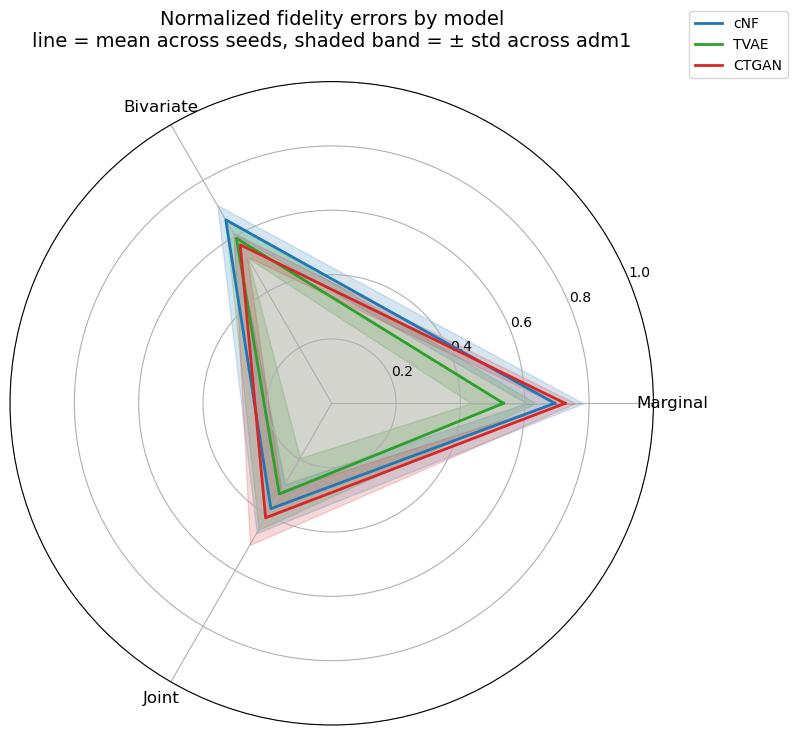

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [14]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/nga_micron")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/nga_micron")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (723, 6)
recall_df: (723, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Abia,0.277454,0.470022,0.691598
1,CTGAN,1,Abuja,0.308493,0.369051,0.685070
2,CTGAN,1,Adamawa,0.199049,0.401401,0.465040
3,CTGAN,1,Akwa Ibom,0.325883,0.500939,0.624292
4,CTGAN,1,Anambra,0.158109,0.422320,0.612965


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Abia,0.328333,197,600,600,0.5
1,cNF,1,Abuja,0.318865,191,599,599,0.5
2,cNF,1,Adamawa,0.396667,238,600,600,0.5
3,cNF,1,Akwa Ibom,0.218333,131,600,600,0.5
4,cNF,1,Anambra,0.305000,183,600,600,0.5


In [16]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Abia,0.277454,0.470022,0.691598,0.479691
1,CTGAN,1,Abuja,0.308493,0.369051,0.685070,0.454205
2,CTGAN,1,Adamawa,0.199049,0.401401,0.465040,0.355163
3,CTGAN,1,Akwa Ibom,0.325883,0.500939,0.624292,0.483705
4,CTGAN,1,Anambra,0.158109,0.422320,0.612965,0.397798


In [17]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (723, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Abia,0.479691,0.125000
1,CTGAN,1,Abuja,0.454205,0.128548
2,CTGAN,1,Adamawa,0.355163,0.288333
3,CTGAN,1,Akwa Ibom,0.483705,0.081667
4,CTGAN,1,Anambra,0.397798,0.101667


In [18]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.199868,0.104010,0.431541,0.068980,185
1,NF,0.377728,0.133083,0.177004,0.036022,185
2,TVAE,0.222902,0.098794,0.517768,0.104038,168
3,cNF,0.283970,0.120987,0.423285,0.146401,185


In [19]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.283970,0.120987,0.423285,0.146401,185
1,TVAE,0.222902,0.098794,0.517768,0.104038,168
2,CTGAN,0.199868,0.104010,0.431541,0.068980,185


In [20]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.283970,0.120987,0.423285,0.146401,185,0.576715
1,TVAE,0.222902,0.098794,0.517768,0.104038,168,0.482232
2,CTGAN,0.199868,0.104010,0.431541,0.068980,185,0.568459


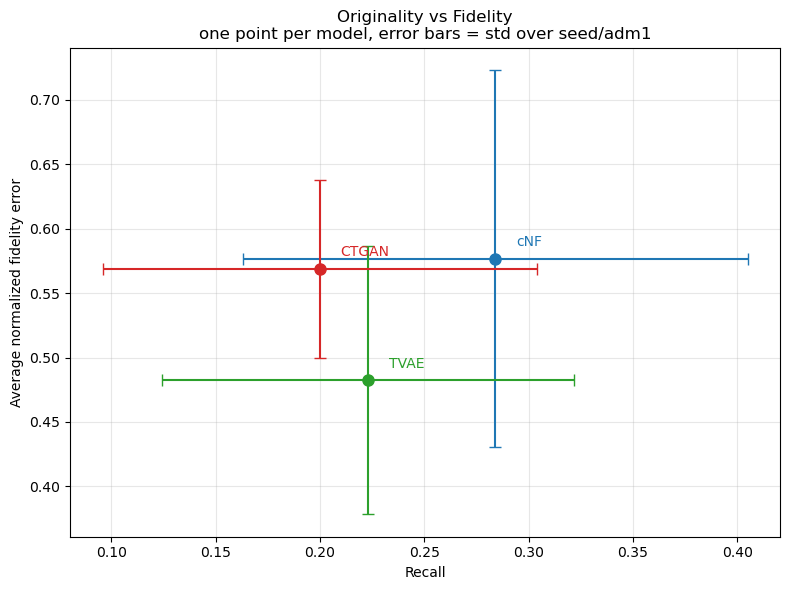

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()